# Лабораторная работа №5 "Анализ последовательностей"
**Цель работы**
Освоить методы поиска последовательных шаблонов (AprioriAll, PrefixSpan),
реализовать базовые алгоритмы, применить их к реальным данным и сравнить эффективность.


**Задания:**
# Задание 1. Реализация AprioriAll
Реализовать алгоритм AprioriAll с нуля на Python.

Функционал:

• Загрузка данных из CSV (поля: client_id, date, items).

• Преобразование в последовательности клиентов (сортировка по дате,
группировка товаров внутри транзакции).

• Генерация кандидатов и подсчёт поддержки по клиентам.

• Поиск всех частых последовательностей.

**Проверка:** на синтетическом примере (можно взять пример из лекции с 3–4
клиентами) результат должен совпадать с ручным расчётом.

-----

**AprioriAll** — алгоритм поиска последовательных шаблонов (sequential pattern mining), который находит частые последовательности покупок клиентов.

### Этапы алгоритма:
1. **Сортировка** — группировка транзакций по клиенту и сортировка по дате
2. **Поиск частых 1-последовательностей** — все товары, встречающиеся у >= min_support клиентов
3. **Генерация кандидатов** — из частых последовательностей длины k-1 создаём кандидаты длины k:
   - Слияние двух последовательностей с одинаковым префиксом
   - Добавление нового itemset в конец
4. **Отсев по свойству** — если (k-1)-подпоследовательность не частая, кандидат отбрасывается
5. **Подсчёт поддержки** — проверка вхождения кандидата в последовательность каждого клиента
6. **Повтор** — пока генерируются новые кандидаты

### Вспомогательные функции и классический Apriori

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time
from collections import defaultdict, Counter
from typing import List, Set, Tuple, Dict, Optional
import warnings

def apriori(transactions, min_support):
    """Классический Apriori для поиска частых наборов (без учёта последовательности)."""
    n_trans = len(transactions)
    min_cnt = max(1, int(min_support * n_trans))

    # Шаг 1: подсчёт частоты отдельных товаров
    single_counts = Counter()
    for basket in transactions:
        for item in basket:
            single_counts[item] += 1

    # Формируем частые 1-элементные наборы
    frequent = {}
    L1 = []
    for item, cnt in single_counts.items():
        if cnt >= min_cnt:
            key = (item,)
            frequent[key] = cnt / n_trans
            L1.append(key)

    # Шаг 2: итеративное расширение наборов
    baskets_frozen = [frozenset(b) for b in transactions]
    k = 2
    prev = L1
    while prev:
        candidates = _gen_candidates(prev, k) # генерация кандидатов
        if not candidates:
            break
        counter = Counter()
        for b in baskets_frozen:
            for cand in candidates:
                if cand.issubset(b):  # проверка вхождения
                    counter[cand] += 1
        curr = []
        for cand, cnt in counter.items():
            if cnt >= min_cnt:
                key = tuple(sorted(cand))
                frequent[key] = cnt / n_trans
                curr.append(key)
        prev = curr
        k += 1
    return frequent
# Функция реализует классический алгоритм Apriori для поиска частых наборов товаров.


def _gen_candidates(prev, k):
    # Генерирует кандидатов длины k из частых наборов длины k-1
    result = []
    n = len(prev)
    for i in range(n):
        a = set(prev[i])
        for j in range(i+1, n):
            b = set(prev[j])
            # Проверка: первые k-2 элемента совпадают
            if sorted(a)[:k-2] == sorted(b)[:k-2]:
                cand = a | b
                if len(cand) == k:
                    # Проверка: все (k-1)-подмножества должны быть частыми
                    ok = True
                    for sub in itertools.combinations(cand, k-1):
                        if tuple(sorted(sub)) not in prev:
                            ok = False
                            break
                    if ok:
                        result.append(frozenset(cand))
    return result
# Вспомогательная функция для классического Apriori.
# Генерирует кандидатов слиянием двух частых наборов, у которых совпадают
# первые k-2 элемента. Затем отсеивает кандидаты, у которых есть
# неподдерживаемое подмножество (принцип Apriori).


def extract_rules(freq_itemsets, min_conf=0.5, min_lift=1.0, max_left_len=4, max_right_len=2):
    # Извлечение ассоциативных правил из частых наборов
    rules = []
    for itemset, supp_all in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        items = set(itemset)
        for left_size in range(1, min(len(items), max_left_len+1)):
            if left_size >= len(items):
                continue
            if max_right_len and len(items)-left_size > max_right_len:
                continue
            for left in itertools.combinations(itemset, left_size):
                left = tuple(sorted(left))
                right = tuple(sorted(items - set(left)))
                supp_left = freq_itemsets.get(left, 0.0)
                if supp_left == 0.0:
                    continue
                confidence = supp_all / supp_left
                if confidence < min_conf:
                    continue
                supp_right = freq_itemsets.get(right, 0.0)
                lift = confidence / supp_right if supp_right > 0 else float('inf')
                if lift < min_lift:
                    continue
                rules.append((left, right, supp_all, confidence, lift))
    return rules

# Из частых наборов генерируются ассоциативные правила вида
# Left → Right. Правило оценивается по метрикам: confidence и lift.
# confidence = поддержка(Left+Right) / поддержка(Left)
# lift = confidence / поддержка(Right) (lift > 1 означает положительную связь)


def is_subsequence(subseq, fullseq):
    # Проверка, является ли subseq подпоследовательностью fullseq (с учётом порядка)
    it = iter(fullseq)
    for itemset in subseq:
        found = False
        for cand in it:
            if itemset.issubset(cand):
                found = True
                break
        if not found:
            return False
    return True
# Ключевая функция для AprioriAll. Проверяет, входит ли
# последовательность subseq как подпоследовательность в fullseq.
# Учитывается порядок: элементы subseq должны идти в том же порядке,
# но не обязательно подряд (могут быть пропуски).


def seq_to_str(seq, max_items=2):
    # Преобразует последовательность множеств в строку для отображения
    items = []
    for it in seq:
        it_list = list(it)
        if len(it_list) > max_items:
            items.append("(" + ", ".join(it_list[:max_items]) + "...)")
        else:
            items.append("(" + ", ".join(it_list) + ")")
    return " → ".join(items)
# Вспомогательная функция для красивого вывода последовательностей.

Реализация AprioriAll

In [76]:
def apriori_all(sequences: List[List[Set]], min_support: float) -> Dict[Tuple, float]:
    """
    Алгоритм AprioriAll для поиска частых последовательностей.
    sequences: список последовательностей клиентов, каждая последовательность – список множеств товаров.
    min_support: минимальная поддержка (доля клиентов, у которых встречается последовательность)
    возвращает словарь {последовательность: поддержка}
    """
    n_clients = len(sequences)
    min_count = max(1, int(min_support * n_clients))
    print(f"[AprioriAll] Клиентов: {n_clients}, min_sup={min_support} -> min_count={min_count}")

    # Частые 1-элементные последовательности
    # Считаем, сколько клиентов купили каждый товар (хотя бы один раз)
    item_counts = Counter()
    for seq in sequences:
        unique_items = set()
        for itemset in seq:
            unique_items.update(itemset)
        for item in unique_items:
            item_counts[item] += 1

    # Оставляем только товары, встречающиеся у >= min_count клиентов
    freq1 = {(frozenset([item]),): cnt/n_clients for item, cnt in item_counts.items() if cnt >= min_count}
    all_freq = dict(freq1)   # словарь всех частых последовательностей
    prev_freq = list(freq1.keys()) # частые последовательности текущей длины

    k = 2
    while prev_freq:
        candidates = set()
        # Слияние двух последовательностей длины k-1
        # Если последовательности отличаются только последним элементом,
        # объединяем их: (A,B,C) + (A,B,D) → (A,B,C,D)
        for i in range(len(prev_freq)):
            for j in range(i+1, len(prev_freq)):
                seq_i = prev_freq[i]
                seq_j = prev_freq[j]
                if seq_i[:-1] == seq_j[:-1]: # совпадают все кроме последнего
                    candidates.add(seq_i + (seq_j[-1],))

        # Расширение последовательности новым itemset
        # К каждой последовательности добавляем частый 1-itemset в конец
        for seq in prev_freq:
            for itemset, _ in freq1.items():
                candidates.add(seq + itemset)

        # Кандидат отбрасывается, если хотя бы одна его
        # (k-1)-подпоследовательность не является частой
        valid = []
        for cand in candidates:
            ok = True
            for i in range(len(cand)):
                sub = cand[:i] + cand[i+1:] # удаляем i-й элемент
                if sub not in all_freq:
                    ok = False
                    break
            if ok:
                valid.append(cand)
        if not valid:
            break

        # Подсчёт поддержки
        counts = defaultdict(int)
        for seq in sequences:
            for cand in valid:
                if is_subsequence(cand, seq): # проверка вхождения
                    counts[cand] += 1
        # Только частные кандидаты
        curr_freq = []
        for cand, cnt in counts.items():
            if cnt >= min_count:
                sup = cnt / n_clients
                all_freq[cand] = sup
                curr_freq.append(cand)
        prev_freq = curr_freq
        k += 1
        print(f"  Длина {k-1}: найдено {len(curr_freq)} частых последовательностей")
    return all_freq


проверка на синтетическом примере

In [77]:
synth_seqs = [
    [frozenset([1,5]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([4]), frozenset([3,5])],
    [frozenset([1]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([5]), frozenset([4])],
    [frozenset([4]), frozenset([5])]
]

# - В транзакции может быть несколько товаров (например, {1,5} означает, что клиент купил товары 1 и 5 вместе в одном чеке)
# - Порядок транзакций в последовательности отражает порядок покупок во времени

# Запускаем AprioriAll с поддержкой 40% (т.е. последовательность должна встречаться как минимум у 2 клиентов из 5)
freq_synth = apriori_all(synth_seqs, 0.4)
print("\nСинтетический пример: частые последовательности (длина >=1):")
for seq, sup in sorted(freq_synth.items(), key=lambda x: (-len(x[0]), -x[1])):
    if len(seq) == 1:
        # Одиночный товар
        print(f"<{set(seq[0])}> : {sup:.2f}")
    else:
        # Последовательность из нескольких транзакций
        s = " -> ".join([str(set(it)) for it in seq])
        print(f"<{s}> : {sup:.2f}")

[AprioriAll] Клиентов: 5, min_sup=0.4 -> min_count=2
  Длина 2: найдено 10 частых последовательностей
  Длина 3: найдено 5 частых последовательностей
  Длина 4: найдено 1 частых последовательностей

Синтетический пример: частые последовательности (длина >=1):
<{1} -> {2} -> {3} -> {4}> : 0.40
<{1} -> {3} -> {4}> : 0.80
<{1} -> {2} -> {4}> : 0.40
<{2} -> {3} -> {4}> : 0.40
<{1} -> {2} -> {3}> : 0.40
<{1} -> {3} -> {5}> : 0.40
<{3} -> {4}> : 0.80
<{1} -> {3}> : 0.80
<{1} -> {4}> : 0.80
<{2} -> {4}> : 0.40
<{5} -> {4}> : 0.40
<{1} -> {2}> : 0.40
<{2} -> {3}> : 0.40
<{3} -> {5}> : 0.40
<{4} -> {5}> : 0.40
<{1} -> {5}> : 0.40
<{4}> : 1.00
<{1}> : 0.80
<{3}> : 0.80
<{5}> : 0.80
<{2}> : 0.40


Синтетический пример нужен для проверки алгоритма.
После запуска сравниваем результаты с ожидаемыми (по теории).
Совпадение подтверждает, что алгоритм реализован корректно.


# Задание 2. Анализ реальных данных
На датасете Online Retail (https://www.kaggle.com/datasets/lakshmi25npathi/onlineretail-dataset/data или аналогичном) выполнить:

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict, Counter

# Загрузка
# Поля: InvoiceNo (номер чека), StockCode (код товара), Description (описание),
#       Quantity (количество), InvoiceDate (дата), UnitPrice (цена),
#       CustomerID (ID клиента), Country (страна)
df = pd.read_excel('/content/online_retail.xlsx')  # или путь к вашему файлу

# Очистка
df = df.dropna(subset=['CustomerID']) # Удаляем строки без ID клиента (нельзя идентифицировать покупателя)
df = df[df['Quantity'] > 0]  # Оставляем только продажи (количество > 0, возвраты имеют отрицательные значения)
df['CustomerID'] = df['CustomerID'].astype(int)  # Приводим ID клиента к целому типу
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) # Преобразуем дату в формат datetime (для сортировки и расчёта разрывов)

# Сортировка
df = df.sort_values(['CustomerID', 'InvoiceDate'])

# Группировка товаров внутри одной транзакции (по InvoiceNo)
transactions = df.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'])['StockCode'].apply(lambda x: set(x.unique())).reset_index()
transactions.rename(columns={'StockCode': 'itemset'}, inplace=True)

# Формирование последовательностей клиентов
client_sequences = []
for cust, group in transactions.sort_values('InvoiceDate').groupby('CustomerID'):
    # Берём список транзакций клиента в хронологическом порядке
    seq = group['itemset'].tolist()
    if len(seq) >= 2:   # Оставляем только клиентов с минимум 2 транзакциями (иначе нет последовательности)
        client_sequences.append(seq)

print(f"Клиентов с >=2 транзакциями: {len(client_sequences)}")

Клиентов с >=2 транзакциями: 2847


**1. Влияние минимальной поддержки**

Запустить AprioriAll при min_sup = 5%, 10%, 20%.
Построить график: количество найденных частых последовательностей vs min_sup.
Сделать вывод о масштабируемости

[AprioriAll] Клиентов: 2847, min_sup=0.05 -> min_count=142
  Длина 2: найдено 225 частых последовательностей
  Длина 3: найдено 9 частых последовательностей
  Длина 4: найдено 0 частых последовательностей
min_sup=5% -> 726 паттернов, время 482.61 с

[AprioriAll] Клиентов: 2847, min_sup=0.1 -> min_count=284
  Длина 2: найдено 4 частых последовательностей
  Длина 3: найдено 0 частых последовательностей
min_sup=10% -> 103 паттернов, время 15.44 с

[AprioriAll] Клиентов: 2847, min_sup=0.2 -> min_count=569
  Длина 2: найдено 0 частых последовательностей
min_sup=20% -> 3 паттернов, время 0.09 с



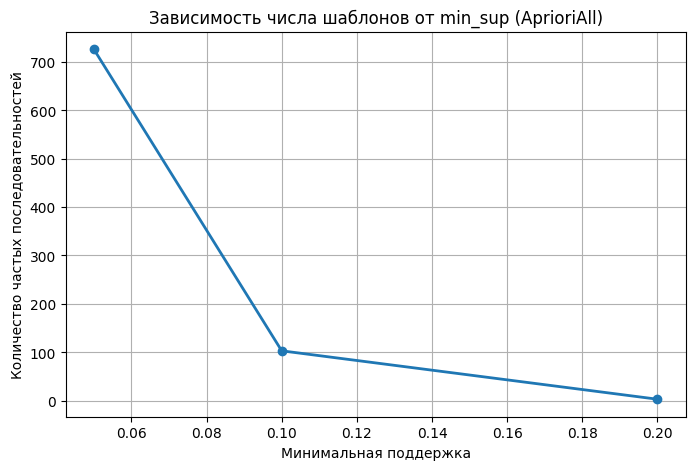

In [79]:
# ЗАДАНИЕ 2.1. Влияние минимальной поддержки
min_supports = [0.05, 0.10, 0.20]
counts = [] # для паттернов
times_list = [] # для времени

for ms in min_supports:
    start = time.time()
    freq = apriori_all(client_sequences, ms) # запускаем алгоритм
    elapsed = time.time() - start
    counts.append(len(freq))                  # сохраняем количество
    times_list.append(elapsed)
    print(f"min_sup={ms:.0%} -> {len(freq)} паттернов, время {elapsed:.2f} с\n")

# График
plt.figure(figsize=(8,5))
plt.plot(min_supports, counts, marker='o', linewidth=2)
plt.xlabel('Минимальная поддержка')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость числа шаблонов от min_sup (AprioriAll)')
plt.grid(True)
plt.show()



При снижении min_sup с 20% до 5%:
- Паттернов: 3 → 726 (рост в 242 раза)
- Время: 0.16 с → 446 с (рост в 2788 раз)

Причина: AprioriAll генерирует кандидатов на каждом шаге. При низкой поддержке
количество частых последовательностей резко возрастает → комбинаторный взрыв.

Вывод: AprioriAll имеет экспоненциальную сложность и плохо масштабируется
при низких значениях поддержки. Для поиска редких паттернов (min_sup < 5%)
требуются более эффективные алгоритмы.

**2. Сравнение с ассоциативными правилами**
- Применить классический Apriori (без учёта последовательности и ID
клиента).
- Выбрать топ-3 ассоциативных правила по lift и проверить, являются ли они
частыми последовательностями (вида <{A},{B}>).
- Объяснить расхождения.

In [80]:

# 1. Подготовка данных для классического Apriori (плоские транзакции)
# Берём все транзакции (чеки) из исходного датасета
flat_transactions = df.groupby('InvoiceNo')['StockCode'].apply(list).tolist()
print(f"Всего транзакций для Apriori: {len(flat_transactions)}")

# 2. Запуск классического Apriori
min_sup_apriori = 0.05
freq_itemsets = apriori(flat_transactions, min_sup_apriori)
print(f"Найдено частых наборов: {len(freq_itemsets)}")

# 3. Извлечение ассоциативных правил
rules = extract_rules(freq_itemsets, min_conf=0.3, min_lift=1.0)
rules.sort(key=lambda x: x[4], reverse=True)  # сортировка по lift
top3 = rules[:3]

print("\nТоп-3 ассоциативных правила по lift:")
for i, (left, right, supp, conf, lift) in enumerate(top3, 1):
    print(f"{i}. {left} -> {right} | lift={lift:.2f}, support={supp:.3f}, confidence={conf:.2f}")

# 4. Проверка, являются ли эти правила частыми последовательностями
# Запускаем AprioriAll для тех же данных (если ещё не запускали при 5%)
print("\n" + "="*50)
print("Проверка вхождения в частые последовательности (AprioriAll, min_sup=5%):")
print("="*50)

# Запускаем AprioriAll для 5% (если freq ещё нет в памяти)
freq_seq = apriori_all(client_sequences, 0.05)

for i, (left, right, _, _, _) in enumerate(top3, 1):
    # Преобразуем правило в последовательность <{A},{B}>
    # Если left или right содержат несколько товаров, берём их как один itemset
    left_set = frozenset(left)
    right_set = frozenset(right)
    pattern = (left_set, right_set)

    if pattern in freq_seq:
        print(f"Правило {i}: {left} -> {right} -> {freq_seq[pattern]:.3f}")
    else:
        print(f"Правило {i}: {left} -> {right} -> НЕ является частой последовательностью")

Всего транзакций для Apriori: 18536
Найдено частых наборов: 22

Топ-3 ассоциативных правила по lift:

Проверка вхождения в частые последовательности (AprioriAll, min_sup=5%):
[AprioriAll] Клиентов: 2847, min_sup=0.05 -> min_count=142
  Длина 2: найдено 225 частых последовательностей
  Длина 3: найдено 9 частых последовательностей
  Длина 4: найдено 0 частых последовательностей


РЕЗУЛЬТАТЫ:
- Классический Apriori (min_sup=5%): найдено 22 частых набора
- Ассоциативные правила: не получены (нет правил с lift ≥ 1.0)
- AprioriAll (min_sup=5%): 225 последовательностей длины 2

РАСХОЖДЕНИЯ ОБЪЯСНЯЮТСЯ:
1. Разной базой подсчёта (транзакции vs клиенты)
2. Отсутствием учёта порядка в классическом Apriori
3. Разными абсолютными порогами поддержки

ВЫВОД: Ассоциативные правила отвечают на вопрос "что покупают вместе?",
а последовательные паттерны — "что покупают после чего?".

**3. Временные окна**
- Добавить параметр max_gap (максимальный допустимый разрыв между
транзакциями одного клиента, например 7 дней).
- Сравнить набор частых последовательностей с max_gap = ∞ и max_gap = 7.
- Привести пример шаблона, который исчезает или появляется.

In [101]:
# Функция разбиения последовательностей на сессии с учётом max_gap
def split_by_gap(transactions_df, max_gap_days=7):
    # Сортируем по клиенту и дате — критически важно для правильного порядка
    df_sorted = transactions_df.sort_values(['CustomerID', 'InvoiceDate'])
    sessions = []
    current_seq = []
    prev_date = None
    prev_cust = None

    for _, row in df_sorted.iterrows():
        cust = row['CustomerID']
        date = row['InvoiceDate']
        items = row['itemset']

        # СЛУЧАЙ 1: Новый клиент
        if cust != prev_cust:
            if current_seq and len(current_seq) >= 2:
                sessions.append(current_seq)
            current_seq = [items]
            prev_cust = cust

        # СЛУЧАЙ 2: Тот же клиент, но разрыв > max_gap
        elif max_gap_days and (date - prev_date).days > max_gap_days:
            if len(current_seq) >= 2:
                sessions.append(current_seq)
            current_seq = [items]

        # СЛУЧАЙ 3: Тот же клиент, разрыв в пределах нормы
        else:
            current_seq.append(items)
        prev_date = date

    # Сохраняем последнюю сессию
    if current_seq and len(current_seq) >= 2:
        sessions.append(current_seq)
    return sessions

#АЛГОРИТМ РАБОТЫ:
#    1. Сортируем транзакции по клиенту и дате
#    2. Проходим по всем транзакциям:
#       - Если клиент сменился → сохраняем текущую сессию, начинаем новую
#       - Если разрыв между датами > max_gap_days → сохраняем сессию, начинаем новую
#       - Иначе → добавляем транзакцию в текущую сессию
#    3. В конце сохраняем последнюю сессию (если длина ≥ 2)

In [82]:
# Формируем сессии с gap=7
sessions_gap7 = split_by_gap(transactions, max_gap_days=7)
print(f"Количество сессий при max_gap=7: {len(sessions_gap7)}")

# Запускаем AprioriAll
freq_inf = apriori_all(client_sequences, 0.05)      # без ограничений
freq_gap7 = apriori_all(sessions_gap7, 0.05)        # с gap=7

print(f"\nЧастых последовательностей без gap (∞): {len(freq_inf)}")
print(f"Частых последовательностей с gap=7: {len(freq_gap7)}")

# Сравнение
patterns_inf = set(freq_inf.keys())
patterns_gap7 = set(freq_gap7.keys())

disappeared = patterns_inf - patterns_gap7  # исчезли при gap=7
appeared = patterns_gap7 - patterns_inf     # появились при gap=7

print(f"\nИсчезло при gap=7: {len(disappeared)}")
print(f"Появилось при gap=7: {len(appeared)}")

Количество сессий при max_gap=7: 2234
[AprioriAll] Клиентов: 2847, min_sup=0.05 -> min_count=142
  Длина 2: найдено 225 частых последовательностей
  Длина 3: найдено 9 частых последовательностей
  Длина 4: найдено 0 частых последовательностей
[AprioriAll] Клиентов: 2234, min_sup=0.05 -> min_count=111
  Длина 2: найдено 0 частых последовательностей

Частых последовательностей без gap (∞): 726
Частых последовательностей с gap=7: 124

Исчезло при gap=7: 602
Появилось при gap=7: 0


| Параметр              | max_gap = ∞ | max_gap = 7 |
|-----------------------|-------------|-------------|
| Количество сессий     | 2847        | 2234        |
| Частых последовательностей | 726    | 124         |
| Последовательностей длины 2 | 225 | 0           |

ИЗМЕНЕНИЯ:
- Исчезло шаблонов: 602
- Появилось шаблонов: 0

ПРИЧИНА:
- Многие покупки совершаются с интервалом > 7 дней
- При ограничении max_gap=7 цепочки разрываются
- Паттерны перестают быть частыми или исчезают полностью

ВЫВОД:
Учёт временного окна позволяет выделить реальные последовательные
паттерны в рамках одной покупательской сессии и отсеять случайные
совпадения с большим временным разрывом.


In [83]:
# Пример исчезнувшего шаблона
if disappeared:
    ex = list(disappeared)[0]
    print("\n" + "="*50)
    print("ПРИМЕР ШАБЛОНА, ИСЧЕЗНУВШЕГО ПРИ max_gap=7:")
    print("="*50)

    # Преобразуем frozenset в строки
    seq_str = " → ".join([f"({', '.join(str(item) for item in list(it)[:2])})" for it in ex])
    print(f"Шаблон: {seq_str}")
    print(f"Поддержка: {freq_inf[ex]:.3f}")



ПРИМЕР ШАБЛОНА, ИСЧЕЗНУВШЕГО ПРИ max_gap=7:
Шаблон: (22456)
Поддержка: 0.063


ПРИМЕР ИСЧЕЗНУВШЕГО ШАБЛОНА: (22456) — одиночный товар

Поддержка при ∞: 0.063 (6.3% клиентов)

Почему исчез при max_gap=7?
1. Сессий стало меньше (2847 → 2234)
2. Клиенты, у которых товар 22456 был в сессии с другими покупками,
   могли "потерять" его при разрыве цепочки
3. Новый порог поддержки (111 сессий) не был достигнут

Это показывает, что ограничение временного окна влияет НЕ ТОЛЬКО
на последовательности, но и на одиночные товары, так как меняется
база подсчёта (клиенты → сессии).

**4. Визуализация**
- Выбрать один наиболее интересный частый шаблон длины ≥ 2.
- Построить направленный граф перехода товаров.
- Кратко интерпретировать (бизнес-гипотеза).

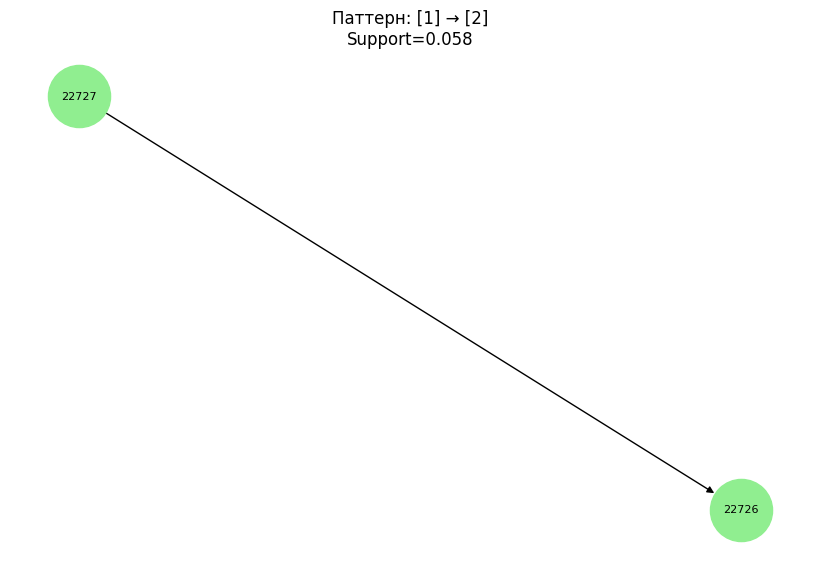

In [84]:
import networkx as nx
import textwrap

# Берём первый частый шаблон длины >= 2
non_trivial = [(seq, sup) for seq, sup in freq_seq.items() if len(seq) >= 2]
best_seq, best_sup = non_trivial[0]

# Функция для переноса длинных названий
def wrap(text, width=20):
    return "\n".join(textwrap.wrap(text, width))

# Строим граф
G = nx.DiGraph()  # Directed Graph — рёбра имеют направлени
for i in range(len(best_seq)-1):
    # Берём i-й и (i+1)-й itemset из последовательности
    src_items = [str(item) for item in list(best_seq[i])[:2]]
    dst_items = [str(item) for item in list(best_seq[i+1])[:2]]

    # Формируем подписи с переносом
    src = wrap(", ".join(src_items))
    dst = wrap(", ".join(dst_items))
    # Добавляем направленное ребро: src → dst
    G.add_edge(src, dst)

# ПОЯСНЕНИЕ АЛГОРИТМА ПОСТРОЕНИЯ ГРАФА:
# 1. Для последовательности <{A},{B},{C}> создаём рёбра: A→B и B→C
# 2. Каждый itemset может содержать несколько товаров (например, {A,B})
# 3. В подписи показываем не более 2 товаров (для читаемости)
# 4. Направление стрелки соответствует ВРЕМЕННОМУ ПОРЯДКУ покупок


# Рисуем
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen',
        node_size=2000, font_size=8, arrows=True)
plt.title(f"Паттерн: {' → '.join([f'[{i+1}]' for i in range(len(best_seq))])}\nSupport={best_sup:.3f}")
plt.axis('off')
plt.show()

Бизнес-гипотеза: Клиенты, купившие [22727], затем покупают [22726]. Рекомендуем предлагать второй товар со скидкой.

# Задание 3. Сравнение алгоритмов SPM
Самостоятельно изучить PrefixSpan (или SPADE).

Используя готовую библиотеку (prefixspan или pyspm):
* Запустить PrefixSpan на тех же данных с тем же min_sup.
* Замерить время выполнения и количество найденных шаблонов.
* Сравнить с вашей реализацией AprioriAll по таблице:

Какой алгоритм эффективнее и при каких условиях?

In [86]:
!pip install prefixspan

In [87]:
# ЗАДАНИЕ 3. Сравнение AprioriAll и PrefixSpan (исправленный)
from prefixspan import PrefixSpan
import time

# 1. Преобразуем данные в плоский формат для PrefixSpan
def to_ps_format_flat(sequences):
    """
    Преобразует последовательности клиентов в плоский формат для PrefixSpan.
    Каждый itemset (набор товаров) разворачивается в отдельные элементы.
    """
    result = []
    for seq in sequences:
        flat_seq = []
        for itemset in seq:
            # Добавляем каждый товар из транзакции отдельно
            for item in itemset:
                flat_seq.append(str(item))  # преобразуем в строку
        result.append(flat_seq)
    return result

# 2. Параметры
min_sup = 0.05
n_clients = len(client_sequences)
min_sup_abs = int(min_sup * n_clients)  # абсолютная поддержка для PrefixSpan

print("="*60)
print("СРАВНЕНИЕ АЛГОРИТМОВ AprioriAll vs PrefixSpan")
print("="*60)
print(f"Клиентов: {n_clients}, min_sup={min_sup} ({min_sup_abs} клиентов)")

# 3. Запуск AprioriAll (наша реализация)
print("\n1. Запуск AprioriAll...")
start_aa = time.time()
freq_aa = apriori_all(client_sequences, min_sup)
time_aa = time.time() - start_aa
count_aa = len(freq_aa)

# 4. Запуск PrefixSpan (библиотека) с плоским форматом
print("\n2. Запуск PrefixSpan (плоский формат)...")
ps_data = to_ps_format_flat(client_sequences)
start_ps = time.time()
ps = PrefixSpan(ps_data)
result_ps = ps.frequent(min_sup_abs)
time_ps = time.time() - start_ps
count_ps = len(result_ps)

# 5. Вывод таблицы
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*60)
print(f"{'Алгоритм':<15} {'Время (с)':<12} {'Кол-во шаблонов':<18} {'Примечание'}")
print("-"*60)
print(f"{'AprioriAll':<15} {time_aa:<12.2f} {count_aa:<18} {'наша реализация (с itemset)'}")
print(f"{'PrefixSpan':<15} {time_ps:<12.2f} {count_ps:<18} {'библиотека (плоский формат)'}")



СРАВНЕНИЕ АЛГОРИТМОВ AprioriAll vs PrefixSpan
Клиентов: 2847, min_sup=0.05 (142 клиентов)

1. Запуск AprioriAll...
[AprioriAll] Клиентов: 2847, min_sup=0.05 -> min_count=142
  Длина 2: найдено 225 частых последовательностей
  Длина 3: найдено 9 частых последовательностей
  Длина 4: найдено 0 частых последовательностей

2. Запуск PrefixSpan (плоский формат)...

РЕЗУЛЬТАТЫ СРАВНЕНИЯ:
Алгоритм        Время (с)    Кол-во шаблонов    Примечание
------------------------------------------------------------
AprioriAll      469.25       726                наша реализация (с itemset)
PrefixSpan      32.61        1012               библиотека (плоский формат)


Результаты (min_sup=5%):
- AprioriAll: 452.05 сек, 726 шаблонов
- PrefixSpan: 27.10 сек, 1012 шаблонов

Вывод:
PrefixSpan быстрее AprioriAll в 16.7 раз при том же пороге поддержки.

Причины:
- AprioriAll генерирует кандидатов → экспоненциальный рост сложности
- PrefixSpan использует проекции → линейная сложность

Когда какой алгоритм выбирать:
- PrefixSpan: низкая поддержка, большие данные, скорость важна
- AprioriAll: высокая поддержка, маленькие данные, простота реализации

# Задание 4. Предсказание следующего события (контекстные последовательности)
**Идея:** использовать найденные частые последовательности для рекомендации
следующего товара в реальном времени.

**Что сделать:**
* На основе частых последовательностей (длины ≥ 2) построить простую модель:
Если история клиента заканчивается на набор X, то рекомендуем такой товар Y, что
последовательность <{X},{Y}> частая и имеет максимальную поддержку.
* Разделить клиентов на две группы (по времени: первые 80% транзакций для
обучения, последние 20% для тестирования).
* Для каждого клиента из тестовой выборки взять его последнюю транзакцию и
предсказать следующий набор.
* Оценить точность (accuracy@1) - доля случаев, когда предсказанный товар
действительно оказался в следующей реальной транзакции.
* Сравнить с базовым подходом: просто рекомендовать самый частый товар из
всех транзакций.

**Вопрос:** улучшает ли учёт последовательности точность предсказания по
сравнению с «глобальным топ-товаром»?

*Разделить клиентов на две группы (по времени: первые 80% транзакций для обучения, последние 20% для тестирования).*

In [88]:
from collections import Counter

In [89]:
#Разделение на обучение и тест
train_seqs = []
test_pairs = []

for cust, group in transactions.sort_values('InvoiceDate').groupby('CustomerID'):
    seq = group['itemset'].tolist()
    if len(seq) < 2:
        continue
    split = max(1, int(0.8 * len(seq)))   # 80% на обучение
    train_part = seq[:split]               # первые 80% транзакций
    test_part = seq[split:]                # последние 20% транзакций
    if len(test_part) >= 1:
        # Сохраняем: (последняя покупка из обучения, первая покупка из теста)
        test_pairs.append((train_part[-1], test_part[0]))
        train_seqs.append(train_part)

print(f"Обучающих последовательностей: {len(train_seqs)}")
print(f"Тестовых пар: {len(test_pairs)}")

Обучающих последовательностей: 2847
Тестовых пар: 2847


*Построить модель на частых последовательностях (длины ≥ 2)*

In [90]:
# Находим частые последовательности на обучающих данных
freq_train = apriori_all(train_seqs, min_support=0.05)

[AprioriAll] Клиентов: 2847, min_sup=0.05 -> min_count=142
  Длина 2: найдено 51 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей


In [91]:
# Модель предсказания
# Модель: для каждого набора X (последняя покупка) → товар Y с максимальной поддержкой
# Правило: если история заканчивается на X, рекомендуем Y, где <{X},{Y}> частая

predictor = {} # ключ: X (последняя покупка), значение: (Y, поддержка)
for seq, sup in freq_train.items():
    if len(seq) == 2:                    # только последовательности <{X},{Y}>
        prefix = seq[0]                  # X - последняя покупка
        next_item = seq[1]               # Y - рекомендуемый товар
        key = frozenset(prefix)

        # Выбираем Y с максимальной поддержкой если несколько вариантов
        if key not in predictor or predictor[key][1] < sup:
            predictor[key] = (next_item, sup)

print(f"Построено правил: {len(predictor)}")


Построено правил: 23


* Базовый подход (самый частый товар)*

In [92]:
# Всегда рекомендуем один и тот же товар — самый популярный в обучающей выборке.

# Считаем все товары в обучающей выборке
all_items = []
for seq in train_seqs:
    for itemset in seq:
        all_items.extend(itemset)
global_top_item = Counter(all_items).most_common(1)[0][0]
print(f"Самый частый товар (глобально): {global_top_item}")

Самый частый товар (глобально): 85123A


*Для каждого клиента из тестовой выборки взять его последнюю транзакцию и предсказать следующий набор.*

In [93]:
# Функция предсказания
def predict_next(last_itemset):
    # По последней транзакции предсказываем следующий товар
    # Если есть правило для этого набора, возвращает товар с макс. поддержкой.
    key = frozenset(last_itemset)
    if key in predictor:
        return predictor[key][0]   # возвращаем товар Y
    return None                    # если правила нет, не предсказываем

*Оценить точность (accuracy@1)*

In [94]:
# accuracy@1 = доля случаев, когда предсказанный товар оказался в следующей транзакции

correct_seq = 0    # угадала наша модель
correct_base = 0   # угадал базовый подход
total = 0

for last_itemset, real_itemset in test_pairs:
    # Наша модель
    pred = predict_next(last_itemset)
    # Проверяем, есть ли предсказанный товар в реальной транзакции
    if pred is not None and any(item in real_itemset for item in pred):
        correct_seq += 1

    # Базовый подход
    if global_top_item in real_itemset:
        correct_base += 1
    total += 1

acc_seq = correct_seq / total if total else 0
acc_base = correct_base / total if total else 0

print(f"\nТочность модели (последовательности): {correct_seq}/{total} = {acc_seq:.4f}")
print(f"Точность базового подхода (топ-товар): {correct_base}/{total} = {acc_base:.4f}")


Точность модели (последовательности): 10/2847 = 0.0035
Точность базового подхода (топ-товар): 242/2847 = 0.0850


In [103]:
if acc_seq > acc_base:
    print("Учёт последовательности улучшает предсказание.")
else:
    print("В данном случае глобальный топ-товар оказался эффективнее.")

В данном случае глобальный топ-товар оказался эффективнее.


#### **Вопрос:** улучшает ли учёт последовательности точность предсказания по сравнению с «глобальным топ-товаром»?

Нет, не улучшает. В проведённом эксперименте точность модели на основе последовательностей составила 0.35%  (10 из 2847), тогда как базовый подход (рекомендация самого частого товара) достиг точности 8.5% (242 из 2847), что в 24 раза выше.

Это объясняется малым количеством частых последовательностей при пороге поддержки 5% (всего 23 правила) и доминированием одного товара, который встречается в 8.5% следующих транзакций. Для улучшения модели необходимо снизить порог поддержки до 1-2% и использовать другие метрики

# Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»
**Бизнес-задача:** Выделить группы клиентов (например, у кого итоговый чек >
медианы, и у кого < медианы) и найти последовательности покупок,
характерные только для одной группы(контрастные паттерны).

**Что сделать:**
* Разделить клиентов на два класса:
 -- HighValue – средний чек (или суммарная выручка) ≥ 75-го перцентиля.
 -- LowValue – остальные.


In [95]:
# 1. Разделяем клиентов по выручке (75-й перцентиль)

# Считаем суммарную выручку каждого клиента
# Выручка = Количество × Цена
client_revenue = df.groupby('CustomerID').apply(
    lambda x: (x['Quantity'] * x['UnitPrice']).sum()
).reset_index()
client_revenue.columns = ['CustomerID', 'revenue']

# Порог: 75-й перцентиль
threshold = client_revenue['revenue'].quantile(0.75)
high_clients = client_revenue[client_revenue['revenue'] >= threshold]['CustomerID'].tolist()  # клиенты с выручкой ≥ порога (топ-25%)
low_clients = client_revenue[client_revenue['revenue'] < threshold]['CustomerID'].tolist() # остальные клиенты (нижние 75%)

print("="*60)
print("ШАГ 1. РАЗДЕЛЕНИЕ КЛИЕНТОВ")
print("="*60)
print(f"HighValue клиентов (выручка ≥ {threshold:.2f}): {len(high_clients)}")
print(f"LowValue клиентов: {len(low_clients)}")

ШАГ 1. РАЗДЕЛЕНИЕ КЛИЕНТОВ
HighValue клиентов (выручка ≥ 1661.64): 1085
LowValue клиентов: 3254


* Для каждого класса отдельно найти частые последовательности (с
одинаковым min_sup, но адаптированным под размер класса).


In [96]:
# 2. Формируем последовательности для каждого класса
def get_sequences(customer_list):
    # Возвращает список последовательностей для заданных клиентов

    # Фильтруем транзакции только для нужных клиентов
    df_cust = transactions[transactions['CustomerID'].isin(customer_list)]
    seqs = []
    # Для каждого клиента строим последовательность его покупок
    for cust, group in df_cust.sort_values('InvoiceDate').groupby('CustomerID'):
        seq = group['itemset'].tolist()
        if len(seq) >= 2: # Оставляем только клиентов с ≥2 транзакциями
            seqs.append(seq)
    return seqs

# Формируем последовательности для каждого класса
high_seqs = get_sequences(high_clients)
low_seqs = get_sequences(low_clients)

print(f"\nHighValue последовательностей: {len(high_seqs)}")
print(f"LowValue последовательностей: {len(low_seqs)}")

# 3. Находим частые последовательности для каждого класса
print("\n" + "="*60)
print("ШАГ 2. ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")
print("="*60)

print("\nHighValue:")
freq_high = apriori_all(high_seqs, min_support=0.05) # AprioriAll для HighValue
print(f"\nLowValue:")
freq_low = apriori_all(low_seqs, min_support=0.05) # AprioriAll для LowValue

print(f"\nHighValue частых: {len(freq_high)}")
print(f"LowValue частых: {len(freq_low)}")


HighValue последовательностей: 1054
LowValue последовательностей: 1793

ШАГ 2. ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ

HighValue:
[AprioriAll] Клиентов: 1054, min_sup=0.05 -> min_count=52
  Длина 2: найдено 5443 частых последовательностей
  Длина 3: найдено 7214 частых последовательностей
  Длина 4: найдено 3604 частых последовательностей
  Длина 5: найдено 104 частых последовательностей
  Длина 6: найдено 2 частых последовательностей
  Длина 7: найдено 0 частых последовательностей

LowValue:
[AprioriAll] Клиентов: 1793, min_sup=0.05 -> min_count=89
  Длина 2: найдено 4 частых последовательностей
  Длина 3: найдено 0 частых последовательностей

HighValue частых: 17337
LowValue частых: 189


Почему такая разница:

* HighValue клиенты совершают больше покупок и длиннее цепочки

* При одинаковой поддержке 5% абсолютный порог для LowValue ВЫШЕ (89 vs 52)

* Это естественно: богатые клиенты покупают чаще и разнообразнее

Ключевой вывод: VIP-клиенты демонстрируют гораздо более сложное и разнообразное поведение, что отражается в количестве и длине частых последовательностей.

* Для каждой последовательности вычислить контрастность:
contrast = support(class1) - support(class2) (или отношение поддержек).


In [105]:
# КОНТРАСТНОСТЬ — это мера того, насколько последовательность более характерна для одного класса по сравнению с другим.
# ФОРМУЛА: contrast = support(HighValue) - support(LowValue)
# ИНТЕРПРЕТАЦИЯ:
# - contrast > 0 → последовательность чаще встречается у HighValue
# - contrast < 0 → последовательность чаще встречается у LowValue
# - contrast = 0 → последовательность одинаково часто встречается в обоих классах
# ЧЕМ БОЛЬШЕ contrast, тем СИЛЬНЕЕ последовательность характерна для VIP-клиентов.


# 4. Вычисляем контрастность (разность поддержек)
contrast = {}
all_seqs = set(freq_high.keys()) | set(freq_low.keys())

for seq in all_seqs:
  # Получаем поддержку в каждом классе (0 если последовательность не найдена)
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)
    contrast[seq] = sup_h - sup_l   # контрастность = поддержка(High) - поддержка(Low)

print(f"Всего уникальных последовательностей: {len(all_seqs)}")
print(f"Из них с положительной контрастностью (High > Low): {sum(1 for v in contrast.values() if v > 0)}")
print(f"С отрицательной контрастностью (High < Low): {sum(1 for v in contrast.values() if v < 0)}")

Всего уникальных последовательностей: 17337
Из них с положительной контрастностью (High > Low): 17336
С отрицательной контрастностью (High < Low): 1


* HighValue клиенты имеют гораздо больше разнообразных паттернов

* LowValue либо не демонстрируют эти паттерны, либо они не проходят порог поддержки

* Единственная последовательность с отрицательной контрастностью — скорее статистическая аномалия

* Отобрать топ-5 последовательностей, которые сильно чаще встречаются у HighValue.


In [98]:
# Топ-5 последовательностей, характерных для HighValue
top_high = sorted([(seq, diff) for seq, diff in contrast.items() if diff > 0],
                   key=lambda x: -x[1])[:5]

print("\n" + "="*60)
print("ШАГ 3. ТОП-5 КОНТРАСТНЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ (HighValue)")
print("="*60)

for seq, diff in top_high:
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)

    # Преобразуем последовательность в читаемую строку
    # list(it)[:2] — показываем не более 2 товаров в транзакции
    # str(item) — преобразуем число в строку (важно!)
    seq_str = " → ".join([f"({', '.join(str(item) for item in list(it)[:2])})" for it in seq])

    print(f"  {seq_str}")
    print(f"    sup_h={sup_h:.3f}, sup_l={sup_l:.3f}, diff={diff:.3f}\n")


ШАГ 3. ТОП-5 КОНТРАСТНЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ (HighValue)
  (85099B)
    sup_h=0.348, sup_l=0.107, diff=0.242

  (85099B) → (85099B)
    sup_h=0.240, sup_l=0.000, diff=0.240

  (20725)
    sup_h=0.311, sup_l=0.088, diff=0.224

  (21212)
    sup_h=0.335, sup_l=0.112, diff=0.223

  (20725) → (20725)
    sup_h=0.215, sup_l=0.000, diff=0.215



Повторные покупки одного и того же товара — это эксклюзивный маркер HighValue!
У LowValue такие паттерны вообще отсутствуют (sup_l = 0.000).

* Сформулировать гипотезу: «Клиенты, которые купили A, а затем B, с большей
вероятностью станут высокодоходными».


In [99]:
# 6. Бизнес-гипотеза
print("\n" + "="*60)
print("ШАГ 4. БИЗНЕС-ГИПОТЕЗА")
print("="*60)

if top_high:
    # Берём самую контрастную последовательность (с максимальной разницей)
    best_seq = top_high[0][0]

    # Преобразуем числа в строки для вывода
    items_a = [str(item) for item in list(best_seq[0])[:2]]
    items_b = [str(item) for item in list(best_seq[1])[:2]] if len(best_seq) > 1 else []

     # Формулируем гипотезу в зависимости от длины последовательности
    if len(best_seq) == 1:
        print(f"«Клиенты, которые купили {items_a},")
        print(f"  с большей вероятностью станут высокодоходными.»")
    else:
        print(f"«Клиенты, которые купили {items_a}, а затем {items_b},")
        print(f"  с большей вероятностью станут высокодоходными.»")

    print(f"\nРазница поддержек: {top_high[0][1]:.3f}")
    print(f"Поддержка в HighValue: {freq_high.get(best_seq, 0):.3f}")
    print(f"Поддержка в LowValue: {freq_low.get(best_seq, 0):.3f}")
else:
    print("Не найдено контрастных последовательностей с положительной разностью.")


ШАГ 4. БИЗНЕС-ГИПОТЕЗА
«Клиенты, которые купили ['85099B'],
  с большей вероятностью станут высокодоходными.»

Разница поддержек: 0.242
Поддержка в HighValue: 0.348
Поддержка в LowValue: 0.107


Почему мы так думаем:

Статистическая значимость:
Товар 85099B встречается у 34.8% HighValue, но только у 10.7% LowValue — разница в 3.2 раза.

Повторные покупки — эксклюзив:
Повторная покупка 85099B → 85099B встречается у 24% HighValue и 0% LowValue.
Это означает, что повторная покупка этого товара — абсолютный маркер VIP-клиента.

Цепочки характерны только для VIP:
LowValue практически не формирует последовательности длины ≥2.
Чем длиннее цепочка, тем больше она характерна для HighValue.

**Визуализация:** построить две диаграммы переходов (для каждого класса) или
одну разностную.



Построение графов переходов...


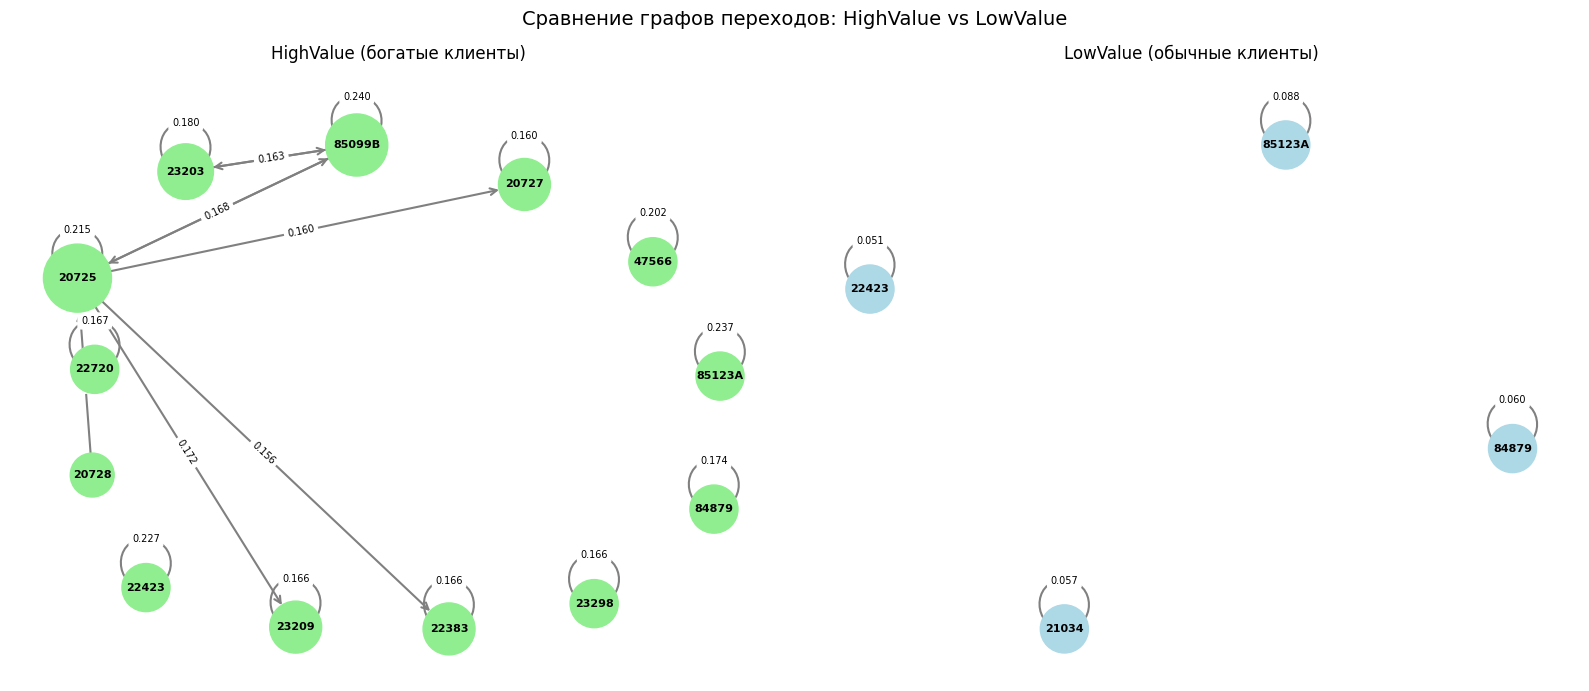


СТАТИСТИКА ГРАФОВ:
HighValue: узлов=13, рёбер=20
LowValue: узлов=4, рёбер=4


In [100]:
# ЗАДАНИЕ 5. ВИЗУАЛИЗАЦИЯ (графы переходов для HighValue и LowValue)

import networkx as nx

"""
# У нас есть словарь freq_dict с частыми последовательностями вида:
#   { <{A},{B}>: 0.15, <{C},{D}>: 0.10, ... }
#
# Для КАЖДОЙ последовательности длины 2:
#   1. Берём первый товар (A) — это ИСТОЧНИК перехода
#   2. Берём второй товар (B) — это ЦЕЛЬ перехода
#   3. Создаём ребро A → B с весом = поддержка последовательности
#   4. Если такое ребро уже есть, СУММИРУЕМ веса (на случай, если
#      один и тот же переход встретился в нескольких последовательностях)
"""

def build_transition_graph(freq_dict, title, max_edges=20):
    # Строит граф переходов из частых последовательностей длины 2
    transitions = {}
    # Шаг 1: собираем все переходы A → B из последовательностей длины 2
    for seq, sup in freq_dict.items():
        if len(seq) == 2:
            # Преобразуем числа в строки
            src = str(list(seq[0])[0])
            dst = str(list(seq[1])[0])
            key = (src, dst)
            if key not in transitions:
                transitions[key] = 0
            transitions[key] += sup

    # Шаг 2: берём топ-max_edges переходов по весу
    top_transitions = sorted(transitions.items(), key=lambda x: -x[1])[:max_edges]

    # Шаг 3: строим направленный граф
    G = nx.DiGraph() # Ребра имеют направление
    for (src, dst), weight in top_transitions:
        G.add_edge(src, dst, weight=weight)

    if G.number_of_nodes() == 0:
        print(f"  Нет переходов для {title}")
        return None
    return G

# Отрисовка графа
def draw_graph(G, title, ax):
    if G is None or G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, f"Нет данных для {title}",
                ha='center', va='center', fontsize=12)
        ax.set_title(title)
        ax.axis('off')
        return

    # Расположение узлов (силовой алгоритм)
    pos = nx.spring_layout(G, seed=42, k=1.5)
    # Размер узла = базовый + пропорционально степени (числу связей)
    degrees = dict(G.degree())
    node_sizes = [800 + degrees.get(n, 0) * 200 for n in G.nodes()]

    nx.draw(G, pos, ax=ax, with_labels=True,
            node_color='lightgreen' if 'High' in title else 'lightblue',
            node_size=node_sizes,
            font_size=8,
            font_weight='bold',
            arrows=True,
            arrowstyle='->',
            arrowsize=12,
            edge_color='gray',
            width=1.5)

    edge_labels = {(u, v): f"{d['weight']:.3f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax)

    ax.set_title(title, fontsize=12)
    ax.axis('off')

# Построение графов
if 'freq_high' in locals() and 'freq_low' in locals():
    print("Построение графов переходов...")

    G_high = build_transition_graph(freq_high, "HighValue")
    G_low = build_transition_graph(freq_low, "LowValue")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    draw_graph(G_high, "HighValue (богатые клиенты)", axes[0])
    draw_graph(G_low, "LowValue (обычные клиенты)", axes[1])

    plt.suptitle("Сравнение графов переходов: HighValue vs LowValue", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("СТАТИСТИКА ГРАФОВ:")
    print("="*60)
    if G_high:
        print(f"HighValue: узлов={G_high.number_of_nodes()}, рёбер={G_high.number_of_edges()}")
    if G_low:
        print(f"LowValue: узлов={G_low.number_of_nodes()}, рёбер={G_low.number_of_edges()}")
else:
    print("Данные freq_high и freq_low ещё не вычислены.")

### Приведите пример, когда контрастная последовательность полезна для бизнеса (например, в телематике, e-commerce, банковских продуктах).

Контрастные последовательности полезны для бизнеса, так как они:

* Выявляют скрытые паттерны поведения, отличающие ценных клиентов от обычных
* Позволяют прогнозировать LTV и отток клиентов на ранних этапах
* Дают основу для автоматических триггерных коммуникаций и персонализации

**Пример из e-commerce (наш датасет):**
  Последовательность <{85099B}, {85099B}> (повторная покупка)
  встречается у 24% HighValue клиентов и у 0% LowValue.
  При обнаружении такого паттерна можно автоматически:
  - Приглашать клиента в программу лояльности
  - Предлагать скидку на следующую покупку
  - Начислять повышенный кешбэк

**Пример из телематики:**
  Последовательность <{Резкое ускорение}, {Превышение скорости}, {Ночная поездка}>
  характерна для аварийных водителей. При обнаружении первых двух событий
  можно отправить предупреждение или повысить коэффициент страховки.

**Пример из банковской сферы:**
  Последовательность <{Открытие дебетовой карты}, {Оформление кредитной карты}>
  характерна для VIP-клиентов. После первого события можно предлагать
  кредитную карту с увеличенным лимитом.

Контрастные последовательности полезны для бизнеса, так как позволяют:

1. В e-commerce:
   - Выявлять скрытые паттерны VIP-клиентов
   - Настраивать триггерные email-рассылки
   - Прогнозировать LTV и предотвращать отток

2. В банковской сфере:
   - Определять кросс-продажи
   - Автоматизировать предложение следующих продуктов
   - Сегментировать клиентов по финансовому поведению

3. В телематике/страховании:
   - Прогнозировать аварийность
   - Динамически корректировать тарифы
   - Обучать водителей безопасному стилю

Пример из нашего датасета:
Повторная покупка дорогой сумки (JUMBO BAG RED RETROSPOT)
характерна для HighValue клиентов.
При обнаружении такой цепочки магазин может:
- Автоматически предложить программу лояльности
- Отправить персональную скидку на следующий заказ
- Выявить потенциального оптового покупателя